In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
# Make plots display nicely
sns.set_theme(style="whitegrid")

# Show all columns
pd.set_option("display.max_columns", None)

In [ ]:
df = pd.read_csv("../data/term-deposit-marketing-2020.csv")

['term-deposit-marketing-2020.csv']

In [ ]:
#First few rows of the dataset
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


In [ ]:
#Dataset shape
df.shape

(40000, 14)

In [ ]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'y'],
      dtype='str')

In [ ]:
#Dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        40000 non-null  int64
 1   job        40000 non-null  str  
 2   marital    40000 non-null  str  
 3   education  40000 non-null  str  
 4   default    40000 non-null  str  
 5   balance    40000 non-null  int64
 6   housing    40000 non-null  str  
 7   loan       40000 non-null  str  
 8   contact    40000 non-null  str  
 9   day        40000 non-null  int64
 10  month      40000 non-null  str  
 11  duration   40000 non-null  int64
 12  campaign   40000 non-null  int64
 13  y          40000 non-null  str  
dtypes: int64(5), str(9)
memory usage: 4.3 MB


In [ ]:
#Dataset description
print(df.describe())

                age        balance           day      duration      campaign
count  40000.000000   40000.000000  40000.000000  40000.000000  40000.000000
mean      40.544600    1274.277550     16.017225    254.824300      2.882175
std        9.641776    2903.769716      8.278127    259.366498      3.239051
min       19.000000   -8019.000000      1.000000      0.000000      1.000000
25%       33.000000      54.000000      8.000000    100.000000      1.000000
50%       39.000000     407.000000     17.000000    175.000000      2.000000
75%       48.000000    1319.000000     21.000000    313.000000      3.000000
max       95.000000  102127.000000     31.000000   4918.000000     63.000000


In [ ]:
import matplotlib.pyplot as plt

numerical_cols = ["age", "balance", "day", "duration", "campaign"]
for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

NameError: name 'df' is not defined

<Figure size 700x400 with 0 Axes>

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'balance'}>],
       [<Axes: title={'center': 'day'}>,
        <Axes: title={'center': 'duration'}>],
       [<Axes: title={'center': 'campaign'}>, <Axes: >]], dtype=object)

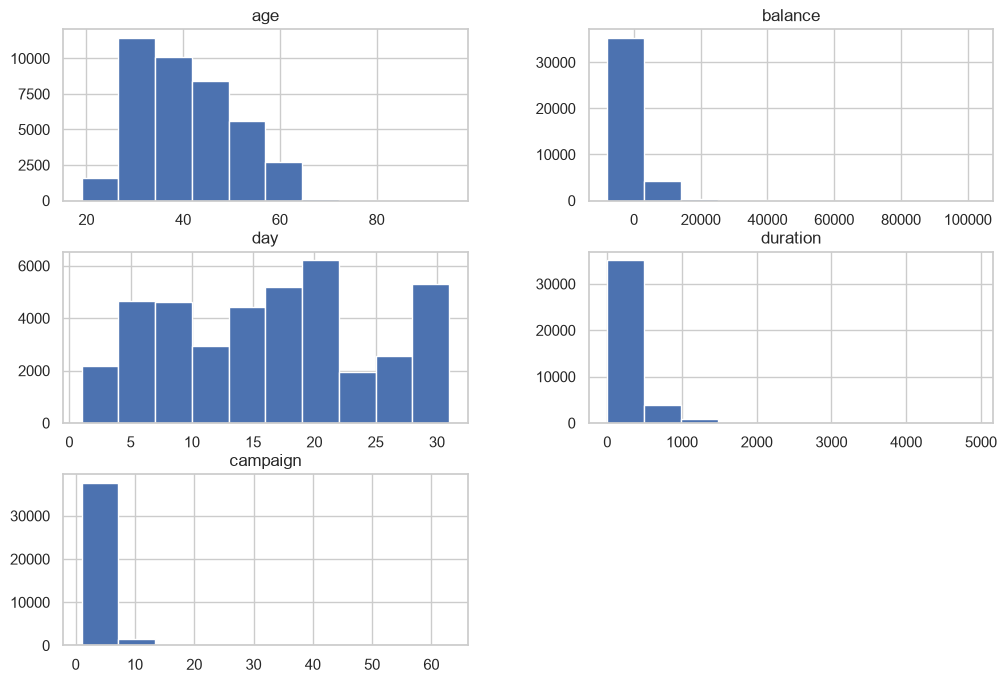

In [24]:
df[["age", "balance", "day", "duration", "campaign"]].hist(figsize=(12, 8))

In [14]:
print("========== Number of Null values ==========")
print(df.isnull().sum())

print("\n========== Number of duplicate rows ==========")
print(df.duplicated().sum())

========== Number of Null values ==========
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
y            0
dtype: int64

========== Number of duplicate rows ==========
0


In [ ]:
#gives a report of the columns and the total number of entries in each column

categorical_cols = df.select_dtypes(include="object").columns

data = []

for col in categorical_cols:
    counts = df[col].value_counts()

    for category, count in counts.items():
        data.append({
            "Feature": col,
            "Category": category,
            "Count": count
        })

categorical_summary = pd.DataFrame(data)

categorical_summary


C:\Users\Shane\AppData\Local\Temp\ipykernel_32976\2296403338.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


,Feature,Category,Count
0,job,blue-collar,9383
1,job,management,8166
2,job,technician,6852
3,job,admin,4483
4,job,services,3910
5,job,retired,1437
6,job,self-employed,1414
7,job,entrepreneur,1405
8,job,unemployed,1104
9,job,housemaid,1087


In [30]:
#percentage of who subscribed for each categorical feature
results = []
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    subscription_rate = df.groupby(col)["y"].apply(
        lambda x: (x == "yes").mean() * 100 #gets the percentage of how many customers chose yes for each category
    )

    for category, rate in subscription_rate.items():
        results.append({
            "Feature": col,
            "Category": category,
            "Subscription Rate (%)": round(rate, 2)
        })

subscription_rates = pd.DataFrame(results)

subscription_rates

C:\Users\Shane\AppData\Local\Temp\ipykernel_32976\3983545112.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


,Feature,Category,Subscription Rate (%)
0,job,admin,7.83
1,job,blue-collar,5.70
2,job,entrepreneur,6.26
3,job,housemaid,4.88
4,job,management,8.28
5,job,retired,10.51
6,job,self-employed,7.92
7,job,services,6.09
8,job,student,15.65
9,job,technician,7.25


In [29]:
#check target percentage distribution
round(df["y"].value_counts(normalize=True) * 100, 2)

#target is imbalanced towards no

y
no     92.76
yes     7.24
Name: proportion, dtype: float64

In [25]:
df.groupby("y")[["age", "balance", "duration", "campaign"]].mean()

,age,balance,duration,campaign
y,,,,
no,40.599208,1249.752533,221.408042,2.918688
yes,39.844959,1588.495856,682.958564,2.414365


In [ ]:
df["y_encoded"] = df["y"].map({"no": 0, "yes": 1}) # change y into a numerical field for correlation
df.select_dtypes(include="number").corr()

,age,balance,day,duration,campaign,y_encoded
age,1.000000,0.081517,-0.011689,-0.036270,0.016204,-0.020273
balance,0.081517,1.000000,0.011662,0.014072,-0.008137,0.030232
day,-0.011689,0.011662,1.000000,-0.032983,0.165429,-0.006420
duration,-0.036270,0.014072,-0.032983,1.000000,-0.088387,0.461169
campaign,0.016204,-0.008137,0.165429,-0.088387,1.000000,-0.040350
y_encoded,-0.020273,0.030232,-0.006420,0.461169,-0.040350,1.000000


The dataset contains 40,000 observations and shows a strong class imbalance in the target variable. Only 7.24% of customers subscribed to the term deposit, while 92.76% did not. 

This imbalance means accuracy will not be able to tell the full story as a model could achieve high overall accuracy simply by predicting that most customers will not subscribe.

Overall, the initial observations suggest that 

- duration: strongest numerical relationship with the target.

- month of contact: Subscription rates vary substantially by month. 

- job: There are noticeable differences between job categories.

- education:  Subscription rates increase with education level

- marital status: There are differences between the groups, not hugem but large enough to warrant further investigation.

- contact method: Customers contacted through cellular had better sunscription rate than when contacted with an unknown method

may contain useful information for predicting term-deposit subscription. 